# LINCS1000 Analysis v2

The following analysis of one or more LINCS1000 transcriptomic datasets is as follows:

- Isolating a cell line of interest
- Identifying compounds of interest
- Overlaying timepoint transcriptomics data from compounds onto the human PPI network
    - Optionally altering edge number based on co-expression
- Embedding resulting graphs into the same embedding space
- Calculating differences between graph embeddings
- Visualising similarities/differences between transcriptomic signatures/graph embeddings

# Packages

In [2]:
#from karateclub import Graph2Vec
import inspect
import itertools
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.figure import Figure
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import pickle
import random
import seaborn as sns
from sklearn.metrics.pairwise import cosine_distances
import tarfile
from typing import Union, get_args
from upsetplot import UpSet, from_indicators, from_memberships
import umap
import warnings

d:\DDesktop\_code\.venv_lincs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Directories

In [3]:
DATAFRAME = "D:/DDesktop/_code/canada/lincs_analysis/dataframes/"
GRAPH = "D:/DDesktop/_code/canada/lincs_analysis/graphs/"
GRAPH_BASE = "D:/DDesktop/_code/canada/lincs_analysis/graphs/base/"
GRAPH_PERTURBAGEN = "D:/DDesktop/_code/canada/lincs_analysis/graphs/perturbagen/"
SIGNATURE = "D:/DDesktop/_code/canada/lincs_analysis/lincs_signatures/"
STRING = "D:/DDesktop/_code/canada/lincs_analysis/string/"
PLOT = "D:/DDesktop/_code/canada/lincs_analysis/plots/"

# Functions

In [4]:
def func_param_typecheck(function, *args, **kwargs) -> None:
    '''
    Checks the types of parameters for a given function based on parameter annotations.

    ### Parameters

    `function`: Any

    - The function whose parameters are being checked.

    `*args`: tuple

    - Tuple of positional parameters for given function, can be any type.

    `**kwargs` : dict

    - Dictionary of keyword arguments passed to the given function, where keys are strings and values are any type.

    ### Raises

    `TypeError`

    - Error raised if any parameter does not match its annotated type
    '''

    ## FUNCTION

    # Get function signature
    function_signature = inspect.signature(function)
    # Get function arguments
    function_arguments = function_signature.bind(*args, **kwargs)

    # Iterate through function parameters and input data types
    for parameter_name, parameter_type in function_arguments.arguments.items():
        # Get expected parameter type from annotation
        expected_type = function_signature.parameters[parameter_name].annotation
        # Check the expected type isn't empty
        if expected_type != inspect.Parameter.empty:
            # Check if parameter annotations are in a Union
            if hasattr(expected_type, '__origin__') and expected_type.__origin__ is Union:
                # Type check
                if not isinstance(parameter_type, get_args(expected_type)):
                    # Extract list of allowed types
                    allowed_types = ', '.join(etype.__name__ for etype in get_args(expected_type))
                    # Raise error
                    raise TypeError(f'Parameter \'{parameter_name}\' must be one of types: \'{allowed_types}\', ' 
                                    f'but got \'{type(parameter_type).__name__}\'')
            # Else type check single annotated type
            elif not isinstance(parameter_type, expected_type):
                # Raise error
                raise TypeError(f'Parameter \'{parameter_name}\' must be of type \'{expected_type.__name__}\', '
                                f'but got \'{type(parameter_type).__name__}\'')

def graph_save(graph: nx.Graph, graph_name: str, path: str = os.getcwd(), graphml: bool = False, report: bool = False) -> None:
    '''
    Saves a NetworkX graph object to specified location using the pickle package OR as a .gml file for downstream analysis.

    ### Parameters

    `graph`: nx.Graph

    > NetworkX graph object to be saved.

    `graph_name`: str

    > Name for saved file.

    `path`: str (default = current working directory)

    > Save location.

    ### Returns

    Pickled graph object
    '''

    ## CHECK

    # Type
    func_param_typecheck(graph_save, graph, graph_name, path, graphml, report)

    ## FUNCTION

    # Check graphml parameter
    if graphml == False:
        # Pickle graph
        with open(f'{path}/{graph_name}.pkl', 'wb') as f:
            pickle.dump(graph, f)
    else:
        # Save graph as .gml file
        nx.write_graphml(graph, path = f'{path}/{graph_name}.gml')

    ## REPORT

    if report == True:
        # Statistics
        num_nodes = len(graph.nodes)
        num_edges = len(graph.edges)
        # Print
        print('>> graph_save')
        if graphml == False:
            print(f'NetworkX graph object w/ {num_nodes:,} nodes and {num_edges:,} edges saved to {path}/{graph_name}.pkl')
        else:
            print(f'NetworkX graph object w/ {num_nodes:,} nodes and {num_edges:,} edges saved to {path}/{graph_name}.gml')
        print()

def graph_load(path: str, graphml: bool = False, report: bool = False) -> nx.Graph:
    '''
    Loads a pickled NetworkX graph object.

    ### Parameters

    `path`: str

    > Location of the pickled graph file.

    ### Returns

    `graph`: nx.Graph

    > NetworkX graph object.
    '''

    ## CHECK

    # Type
    func_param_typecheck(graph_load, path, graphml, report)

    ## FUNCTION

    # Check graphml parameter
    if graphml == False:
        with open(f'{path}', 'rb') as f:
            graph = pickle.load(f)
    else:
        graph = nx.read_graphml(path)
        graph = nx.relabel_nodes(graph, lambda x: int(x))

    ## REPORT

    if report == True:
        # Statistics
        num_nodes = graph.number_of_nodes()
        num_edges = graph.number_of_edges()
        # Print
        print('>> graph_load')
        if graphml == False:
            print(f'Pickled NetworkX graph object with {num_nodes:,} nodes and {num_edges:,} edges loaded from {path}')
        else:
            print(f'GraphML NetworkX graph object with {num_nodes:,} nodes and {num_edges:,} edges loaded from {path}')
        print()

    return graph

def graph_map_nodes(graph: nx.Graph, node_map: dict):
    '''
    Relabels nodes in a graph as integers based on a node map dictionary.
    '''

    ## FUNCTION
    graph = nx.relabel_nodes(graph, node_map)

    return graph

def graph_visualise_network(graph: nx.Graph, pos: dict, cell_line: str, drug: str, dosage: int, timepoint: int, figx: Union[float, int] = 10, figy: Union[float, int] = 10, cmap: str = 'seismic', vmin: Union[float, int] = 0.1, vmax: Union[float, int] = 0.1, edge_factor: Union[float, int] = 500, edge_colour: str = 'black', edge_alpha: float = 0.5, colourbar : bool = True, title: bool = False, title_text: str = '') -> Figure:
#def graph_visualise_network(graph: nx.Graph, pos: dict, cell_line: str, drug: str, dosage: int, timepoint: int, figx: Union[float, int] = 10, figy: Union[float, int] = 10, cmap: str = 'seismic', edge_factor: Union[float, int] = 500, edge_colour: str = 'black', edge_alpha: float = 0.5, colourbar : bool = True, title: bool = False, title_text: str = '') -> Figure:    
    '''
    Plots a NetworkX graph object as a standard network. Must be passed a graph with nested cell line, drug, dosage and timepoint node attributes. Allows for some nodes to lack node attributes.

    ### Parameters

    `graph`: nx.Graph

    > NetworkX graph object to be visualised.

    `pos`: dict

    > Positional data for graph object.

    `cell_line`: str

    > Cell line used to filter graph node attributes e.g. 'HT29'

    `drug`: str

    > Drug name used to filter graph node attributes e.g. 'ibuprofen'

    `dosage`: str

    > Dosage value used to filter graph node attributes, in uM e.g. '10'

    `timepoint`: int

    > Timepoint value used to filter graph node attributes e.g. 6

    `figx`: float, int (default = 10)

    > X-axis size of plot.

    `figy`: float, int (default = 10)

    > Y-axis size of plot.

    `cmap`: str (default = 'seismic')

    > Colourmap used to represent CD-coefficient node attribute value in plot. Diverging colourmap is recommended.    

    `vmin`: float, int (default = -0.1)

    > Minimum value for `colourmap`

    `vmax`: float, int (default = 0.1)

    > Maximum value for `colourmap`

    `edge_factor`: float, int (default = 500)

    > Factor by which the edge weights are divided for visualisation. Higher value is recommended if using combined score directly from STRING data.

    `edge_colour`: str (default = 'black')

    > Colour for plotted edges.

    `edge_alpha`: float (default = 0.5)

    > Alpha value for plotted edges.

    `colourbar`: bool (default = True)

    > Adds a colourbar to the plot.

    ### Returns

    A NetworkX visualisation of a graph, overlayed with LINCS1000 CD-coefficient values from a defined filter of attributes.

    '''

    ## CHECK

    # Type
    func_param_typecheck(graph_visualise_network, graph, pos, cell_line, drug, dosage, timepoint, figx, figy, cmap, vmin, vmax, edge_factor, edge_colour, edge_alpha, colourbar, title, title_text)
    #func_param_typecheck(graph_visualise_network, graph, pos, cell_line, drug, dosage, timepoint, figx, figy, cmap, edge_factor, edge_colour, edge_alpha, colourbar, title, title_text)

    ## FUNCTION
    
    # Initialise lists
    nodes_with_vals = []
    nodes_without_vals = []
    values = [] 
    edge_weights = [graph[u][v]['weight']/edge_factor for u, v in graph.edges()]

    # Iterate through nodes
    for node in graph.nodes:
        # Filter for all attributes
        filter_value = (graph.nodes[node]
                        .get(cell_line, {})
                        .get(drug, {})
                        .get(dosage, {})
                        .get(timepoint))

        # Check filter_value
        if filter_value is not None:
            # Append node to list
            nodes_with_vals.append(node)
            # Append value to list
            values.append(filter_value)
        else:
            # Append node to list
            nodes_without_vals.append(node)


    # Conver values to numpy array
    values_array = np.array(values)
    # Calculate metrics
    q1 = np.nanpercentile(values_array, 25)
    q3 = np.nanpercentile(values_array, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    print(lower_bound)
    print(upper_bound)
    
    ## PLOT

    # Initialise plot
    plt.figure(figsize = (figx, figy))
    
    # Draw edges
    plot_edges = nx.draw_networkx_edges(graph, pos = pos, width = edge_weights, edge_color = edge_colour, alpha = edge_alpha)
    # Draw nodes without values
    plot_nodes_without = nx.draw_networkx_nodes(graph, pos = pos, nodelist = nodes_without_vals, node_color = 'lightgrey', edgecolors = 'black')
    # Draw nodes with values
#    plot_nodes_with = nx.draw_networkx_nodes(graph, pos = pos, nodelist = nodes_with_vals, node_color = values, cmap = 'seismic_r', vmin = lower_bound, vmax = upper_bound, edgecolors = 'black')
    plot_nodes_with = nx.draw_networkx_nodes(graph, pos = pos, nodelist = nodes_with_vals, node_color = values, cmap = 'seismic_r', vmin = vmin, vmax = vmax, edgecolors = 'black')

    # Check colorbar parameter
    if colourbar == True:
        # Generate colorbar
        cbar = plt.colorbar(plot_nodes_with, label = 'CD-coefficient', orientation = 'horizontal', fraction= 0.02)
        # Set position
        cbar.ax.set_position([0.75, 0.85, 0.15, 0.02])

    # Remove border
    plt.box(False)

    # Define title
    if title == True:
        plt.title(f'{title_text}')
        #plt.title(f'Human STRING PPI network w/ CD-coefficient values from {drug}-treated {cell_line} cells ({dosage}uM) at {timepoint}h')
    # Show plot
    plt.show()

def graph_visualise_hex(graph, pos, cell_line, drug, dosage, timepoint, vmin = 0, vmax = 10, gridsize: int = 20):
    '''
    Visualises a given network as 2 separate hex distribution plots
    '''

    # Convert pos to dataframe
    node_coords = pd.DataFrame(pos).T
    node_coords.columns = ['x', 'y']

    # Define nodes with attributes
    attr_nodes = attr_nodes = [node for node in graph.nodes if graph.nodes[node].get(cell_line, {})]
    # Get upregulated nodelist
    unodes = [node for node in attr_nodes if graph.nodes[node][cell_line][drug][dosage][timepoint] > 0]
    # Get upregulated positions
    ucoords = node_coords[node_coords.index.isin(unodes)]
    # Get downregulated nodelist
    dnodes = [node for node in attr_nodes if graph.nodes[node][cell_line][drug][dosage][timepoint] < 0]
    # Get downregulated positions
    dcoords = node_coords[node_coords.index.isin(dnodes)]
    
    # Define empty colourmap
    empty_cmap = mcolors.LinearSegmentedColormap.from_list('', ['gainsboro','gainsboro','gainsboro'])
    #empty_cmap = mcolors.LinearSegmentedColormap.from_list('', ['slategrey','slategrey','slategrey'])

    # Initialise figure w/ subplots
    fig, axes = plt.subplots(1, 2, figsize = (30, 14), sharex = True, sharey = True)

    extent_vals = (-1, 1, -1, 1)

    #fig.suptitle("6h", fontsize=24)

    # Upregulated plot
    axes[0].hexbin(node_coords['x'], node_coords['y'], gridsize = gridsize, cmap = empty_cmap, mincnt=1, alpha=1, linewidth=1, edgecolors='white', extent=extent_vals)
    axes[0].hexbin(ucoords['x'], ucoords['y'], gridsize=gridsize, cmap='Blues', mincnt=1, alpha=1, linewidths=1, edgecolors='dodgerblue', extent=extent_vals, vmin = vmin, vmax = vmax)
    #axes[0].set_title('Upregulated')

    # Downregulated plot
    axes[1].hexbin(node_coords['x'], node_coords['y'], gridsize = gridsize, cmap = empty_cmap, mincnt=1, alpha=1, linewidth=1, edgecolors='white', extent=extent_vals)
    axes[1].hexbin(dcoords['x'], dcoords['y'], gridsize=gridsize, cmap='Reds', mincnt=1, alpha=1, linewidths=1, edgecolors='indianred', extent=extent_vals, vmin = vmin, vmax = vmax)
    #axes[1].set_title('Downregulated')

    # Format plot
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)

    # # Initialise figure
    # plt.figure(figsize = (10,10))
    #     
    # # Generate background hex plot (grey)
    # plt.hexbin(node_coords['x'], node_coords['y'], gridsize = gridsize, cmap = empty_cmap, mincnt = 1, alpha = 1, linewidth = 1, edgecolors = 'white', extent = (-1, 1, -1, 1))
    # # Generate upregulated hex plot
    # plt.hexbin(ucoords['x'], ucoords['y'], gridsize = gridsize, cmap = 'Blues', mincnt = 1, alpha = 1, linewidths = 1, edgecolors = 'dodgerblue', extent = (-1, 1, -1, 1))
    # # Generate down regulated hex plot
    # plt.hexbin(dcoords['x'], dcoords['y'], gridsize = gridsize, cmap = 'Reds', mincnt = 1, alpha = 1, linewidths = 1, edgecolors = 'indianred', extent = (-1, 1, -1, 1))
    # plt.show()
    
    plt.show()

# Graph Comparison

## PPI

In this section, STRINGdb data is converted into an annotated edgelist

### `string_edgelist`

In [26]:
# Import data
string_edgelist = pd.read_csv(STRING + '9606.protein.physical.links.full.v12.0.txt.gz', compression = 'gzip', sep = ' ')
# Show data
string_edgelist.head()

,protein1,protein2,homology,experiments,experiments_transferred,database,database_transferred,textmining,textmining_transferred,combined_score
0,9606.ENSP00000000233,9606.ENSP00000257770,0,312,0,0,0,0,0,311
1,9606.ENSP00000000233,9606.ENSP00000226004,0,162,0,0,0,0,0,161
2,9606.ENSP00000000233,9606.ENSP00000434442,0,0,0,500,0,0,0,499
3,9606.ENSP00000000233,9606.ENSP00000262455,0,531,0,0,0,0,0,531
4,9606.ENSP00000000233,9606.ENSP00000303145,0,0,0,500,0,0,0,499


### `string_info`

In [27]:
# Import protein info
string_info = pd.read_csv(STRING + '9606.protein.info.v12.0.txt.gz', compression = 'gzip', sep = '\t')
# Show data
string_info.head()

,#string_protein_id,preferred_name,protein_size,annotation
0,9606.ENSP00000000233,ARF5,180,ADP-ribosylation factor 5; GTP-binding protein...
1,9606.ENSP00000000412,M6PR,277,Cation-dependent mannose-6-phosphate receptor;...
2,9606.ENSP00000001008,FKBP4,459,"Peptidyl-prolyl cis-trans isomerase FKBP4, N-t..."
3,9606.ENSP00000001146,CYP26B1,512,Cytochrome P450 26B1; Involved in the metaboli...
4,9606.ENSP00000002125,NDUFAF7,441,"Protein arginine methyltransferase NDUFAF7, mi..."


### `df_string`

In [28]:
warnings.filterwarnings('ignore')

## GENERATE DF_STRING
# Copy dataframe
df_string = string_edgelist.copy(deep = True)
# Drop columns
df_string = df_string[['protein1', 'protein2', 'combined_score']]

## MERGE DF_STRING + STRING_INFO
# Rename columns for merge
string_info.rename(columns = {'#string_protein_id' : 'protein1'}, inplace = True)
# Merge
df_string = pd.merge(df_string, string_info[['protein1', 'preferred_name', 'annotation']], how = 'left', on = 'protein1')
# Rename columns for merge
string_info.rename(columns = {'protein1' : 'protein2'}, inplace = True)
# Merge
df_string = pd.merge(df_string, string_info[['protein2', 'preferred_name', 'annotation']], how = 'left', on = 'protein2')
# Reset string_info
string_info.rename(columns = {'protein2' : '#string_protein_id'}, inplace = True)

## FORMAT DF_STRING
# Rename columns
old_names = df_string.columns
new_names = new_names = ['source_id', 'target_id', 'weight', 'source', 'source_annot', 'target', 'target_annot']
for old, new in zip(old_names, new_names):
    df_string.rename(columns = {old : new}, inplace = True)
# Remove taxon ID
for column in ['source_id', 'target_id']:
    df_string[column] = df_string[column].str.replace('9606.', '')
# Column order
column_order = ['source', 'target', 'source_id', 'target_id', 'source_annot', 'target_annot', 'weight']
df_string = df_string[column_order]

# Save data
df_string.to_csv(DATAFRAME + 'df_string.csv', index = False)

# Show data
df_string.head()

,source,target,source_id,target_id,source_annot,target_annot,weight
0,ARF5,NT5E,ENSP00000000233,ENSP00000257770,ADP-ribosylation factor 5; GTP-binding protein...,5'-nucleotidase; Hydrolyzes extracellular nucl...,311
1,ARF5,DUSP3,ENSP00000000233,ENSP00000226004,ADP-ribosylation factor 5; GTP-binding protein...,Dual specificity protein phosphatase 3; Shows ...,161
2,ARF5,ARFGAP2,ENSP00000000233,ENSP00000434442,ADP-ribosylation factor 5; GTP-binding protein...,ADP-ribosylation factor GTPase-activating prot...,499
3,ARF5,ERP44,ENSP00000000233,ENSP00000262455,ADP-ribosylation factor 5; GTP-binding protein...,Endoplasmic reticulum resident protein 44; Med...,531
4,ARF5,TMED10,ENSP00000000233,ENSP00000303145,ADP-ribosylation factor 5; GTP-binding protein...,Transmembrane emp24 domain-containing protein ...,499


## Base Graph

In this section, the foundational human PPI graph is generated as a NetworkX graph object. The global node mapping from this graph is extracted to allow for standardisation in following graphs.

### `graph_base`

In [1]:
# Load data
df_string = pd.read_csv(DATAFRAME + 'df_string.csv')
# Generate graph
graph_base = nx.from_pandas_edgelist(df_string[['source', 'target', 'weight']], source = 'source', target = 'target', edge_attr = 'weight')
# Save graph
graph_save(graph_base, graph_name = 'graph_base', path = GRAPH_BASE, graphml= False, report = True)

NameError: name 'pd' is not defined

### Global Mapping

In [152]:
# Extract all unique node labels
unique_nodes = sorted(graph_base.nodes())
# Generate node map
node_map = {node: i for i, node in enumerate(unique_nodes)}

## Transcriptomics

In this section, CD-coefficient data from various LINCS1000 datasets (below) are converted to a master dataframe.

| Perturbagen   | Timepoint 1   | Timepoint 2   |
|------------|------------|------------|
| Ibuprofen | [6h](https://maayanlab.cloud/sigcom-lincs/#/Signatures/d112be63-97be-56d8-99a4-fbfbeeec08be) | [24h](https://maayanlab.cloud/sigcom-lincs/#/Signatures/601e668e-341e-519c-98a4-437ed919184f) |
| Indoprofen | [6h](https://maayanlab.cloud/sigcom-lincs/#/Signatures/b386b7ef-0589-55e8-8e5e-9dd9c34c1cad) | [24h](https://maayanlab.cloud/sigcom-lincs/#/Signatures/cdffe1c9-4bb2-5725-a5b5-009a5192ea5a) |
| Rifaximin | [6h](https://maayanlab.cloud/sigcom-lincs/#/Signatures/7d8df801-8bd8-5438-9dc4-5347d2913e9b) | [24h](https://maayanlab.cloud/sigcom-lincs/#/Signatures/72a6a194-9959-5672-b030-41f2091f123f) |
| Mefloquine | [6h](https://maayanlab.cloud/sigcom-lincs/#/Signatures/dd3ce4a8-31c8-54fa-8bd9-09dac9eb999c) | [24h](https://maayanlab.cloud/sigcom-lincs/#/Signatures/98d0803f-9a9e-568e-81a4-f68cf581fde6) |

### `df_signature`

In [321]:
# Initialise dataframe
df_signature = pd.DataFrame()

## GENERATE DF_SIGNATURE
# Iterate through files in SIGNATURE
for file in os.listdir(SIGNATURE):
    
    # Get filename
    filename = file.split('.tsv')[0]
    # Get file information
    cell_line = filename.split('_')[4]
    dosage = filename.split('_')[8]
    drug = filename.split('_')[7]
    timepoint = filename.split('_')[5]

    # Import data
    df = pd.read_csv(SIGNATURE + file, sep = '\t')
    # Add columns
    for column_name, column_value in zip(['cell_line', 'dosage', 'drug', 'timepoint'], [cell_line, dosage, drug, timepoint]):
        df[column_name] = column_value
    
    # Append dataframe
    df_signature = pd.concat([df_signature, df], ignore_index = True)

## FORMAT
# Rename columns
df_signature.rename(columns = {'symbol' : 'node_name', 'CD-coefficient' : 'dexp'}, inplace = True)
# Remove hour string from timepoint
df_signature['timepoint'] = df_signature['timepoint'].str.replace('H', '')
# Force timepoint data type to integer
df_signature['timepoint'] = df_signature['timepoint'].astype(int)
# Remove concentration string from dosage
df_signature['dosage'] = df_signature['dosage'].str.replace('uM', '')
# Remove anything after a space in dosage
df_signature['dosage'] = df_signature['dosage'].str.replace(r'\s.*', '', regex=True)

# Save data
df_signature.to_csv(DATAFRAME + 'df_signature.csv', index = False)

# Show data
df_signature.head()

,node_name,dexp,cell_line,dosage,drug,timepoint
0,A1CF,0.009446,HT29,10,mepacrine,24
1,A2M,0.007253,HT29,10,mepacrine,24
2,A4GALT,0.004452,HT29,10,mepacrine,24
3,A4GNT,0.002140,HT29,10,mepacrine,24
4,AAAS,-0.000606,HT29,10,mepacrine,24


## Perturbagen Graphs

In this section `df_signature` is used to assign node attribute values to copies of `base_graph` to generate a set of perturbagen-specific graphs

In [5]:
# Load base graph
graph_base = graph_load(GRAPH_BASE + 'graph_base.pkl', graphml = False)
# Load data
df_signature = pd.read_csv(DATAFRAME + 'df_signature.csv')

# Define lists
list_cells = list(pd.unique(df_signature['cell_line'])) 
list_drugs = list(pd.unique(df_signature['drug'])) 
list_doses = list(pd.unique(df_signature['dosage'])) 
list_times = list(pd.unique(df_signature['timepoint']))

print('Combination lists defined')
print('Defining combination-specific signal graphs...')
print()

# Iterate through combinations of cell line, drug, dosage, timepoint in `df_signature`
for cell_line, drug, dosage, timepoint in itertools.product(list_cells, list_drugs, list_doses, list_times):

    # Slice `df_signature` using the variables
    slice_signature = df_signature[(df_signature['cell_line'] == cell_line) & 
                                   (df_signature['drug'] == drug) & 
                                   (df_signature['dosage'] == dosage) & 
                                   (df_signature['timepoint'] == timepoint)]
    
    # Set node labels as index
    slice_signature.set_index('node_name', inplace = True)

    # Drop columns
    slice_signature = slice_signature[['dexp']]

    # Copy base graph
    slice_graph = graph_base.copy()
    # Set `dexp` values as node attribute
    nx.set_node_attributes(slice_graph, slice_signature['dexp'].to_dict(), name = 'dexp')
    
    # Iterate through nodes
    for node in slice_graph.nodes:
        # Check for those without a `dexp` attribute
        if 'dexp' not in slice_graph.nodes[node]:
            # Provide 0 as default value
            slice_graph.nodes[node]['dexp'] = 0
    
    # Apply node mapping
    slice_graph = graph_map_nodes(slice_graph, node_map = node_map)

    # Save graph
    graph_save(slice_graph, path = GRAPH_PERTURBAGEN, graph_name = f'{cell_line}_{drug}_{dosage}uM_{timepoint}', graphml = False)

Combination lists defined
Defining combination-specific signal graphs...



NameError: name 'node_map' is not defined

# Visualisation

In this section, examples of graph visualisation using standard network and more advanced hexbin plots are given using ego-subgraphs

## Nested Node Attributes

In [6]:
# Iterate through `df_signature` and assign nested node attributes to `graph_base`
for _, row in df_signature.iterrows():
    
    # Define values
    node = row['node_name']
    cell_line = row['cell_line']
    drug = row['drug']
    dosage = row['dosage']
    timepoint = row['timepoint']
    value = row['dexp']

    # Check if node is in graph
    if node in graph_base.nodes:
        # Check if cell_line exists in node attributes
        if cell_line not in graph_base.nodes[node]:
            graph_base.nodes[node][cell_line] = {}
        # Check if drug exists in node attributes
        if drug not in graph_base.nodes[node][cell_line]:
            graph_base.nodes[node][cell_line][drug] = {}
        # Check if dosage exists in node attributes
        if dosage not in graph_base.nodes[node][cell_line][drug]:
            graph_base.nodes[node][cell_line][drug][dosage] = {}

        # Add/update nested timepoint value
        graph_base.nodes[node][cell_line][drug][dosage][timepoint] = value

## Ego Graph

In [7]:
# Get random node
random_node = random.choice(list(graph_base.nodes))

# Check number of neighbours
num_neighbours = len(list(graph_base.neighbors(random_node)))
print(f'{random_node} node selected w/ {num_neighbours:,} neighbours')  

BRD1 node selected w/ 340 neighbours


In [22]:
# Generate RANDOM ego graph
#ego_graph = nx.ego_graph(graph_base, random_node, radius = 1)

# Generate SPECIFIC ego graph
ego_graph = nx.ego_graph(graph_base, 'MT-CO2', radius = 1)

# Generate positional data
ego_pos = nx.kamada_kawai_layout(ego_graph, scale = 2)

In [571]:
# Get distribution of values across axes
df_positions = pd.DataFrame(ego_pos).T  # Transpose to get nodes as rows
df_positions.columns = ['x', 'y']  # Rename columns
df_positions.head()

,x,y
DDX51,0.605003,0.580979
RPL22L1,0.995109,-0.191000
FLT3LG,0.848444,-1.206090
PRR11,0.338643,1.018395
WDR46,0.504011,0.985210


In [585]:
# Add values
node_list = list(df_positions.index)
value_list = []

# Iterate through graph nodes
for node in node_list:
    # Filter for all attributes
    filter_value = (ego_graph.nodes[node]
                    .get('HT29', {})
                    .get('ibuprofen', {})
                    .get(10, {})
                    .get(6))
    
    # Check filter
    if filter_value is not None:
        # Append value
        value_list.append(filter_value)
    else:
        # Append zero
        value_list.append(0)

# Add values to df_positions
df_positions['values'] = value_list
df_positions.head()

,x,y,values
DDX51,0.605003,0.580979,0.002552
RPL22L1,0.995109,-0.191000,0.000000
FLT3LG,0.848444,-1.206090,0.001159
PRR11,0.338643,1.018395,0.001641
WDR46,0.504011,0.985210,0.004710


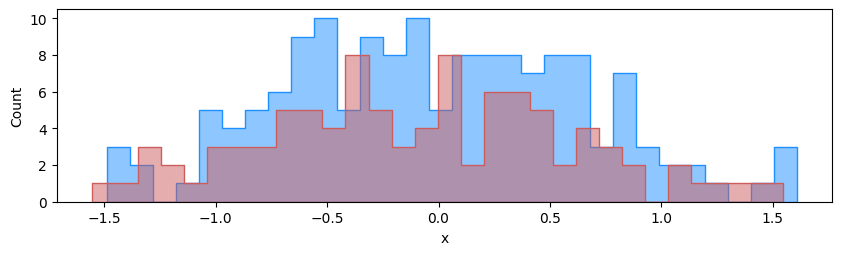

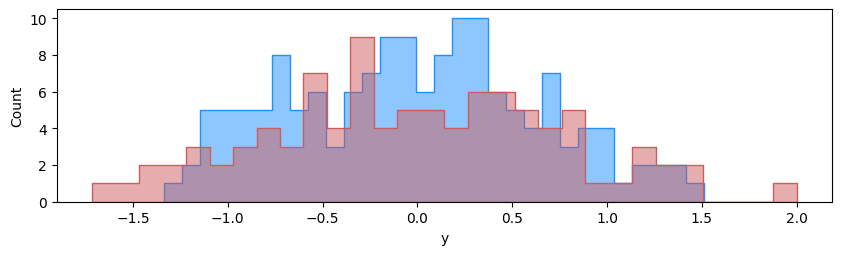

In [607]:
num_bins = 30
val_alpha = 0.5
pltx = 10
plty = 2.5

plt.figure(figsize = (pltx, plty))
# X - positive
sns.histplot(df_positions[df_positions['values'] > 0], x = 'x', bins = num_bins, color = 'dodgerblue', element = 'step', alpha = val_alpha)
# X - negative
sns.histplot(df_positions[df_positions['values'] < 0], x = 'x', bins = num_bins, color = 'indianred', element = 'step', alpha = val_alpha)
plt.show()
plt.figure(figsize = (pltx, plty))
# Y - positive
sns.histplot(df_positions[df_positions['values'] > 0], x = 'y', bins = num_bins, color = 'dodgerblue', element = 'step', alpha = val_alpha)
# Y - negative
sns.histplot(df_positions[df_positions['values'] < 0], x = 'y', bins = num_bins, color = 'indianred', element = 'step', alpha = val_alpha)
plt.show()

## Standard Plot

-0.02388769625
0.02019229375


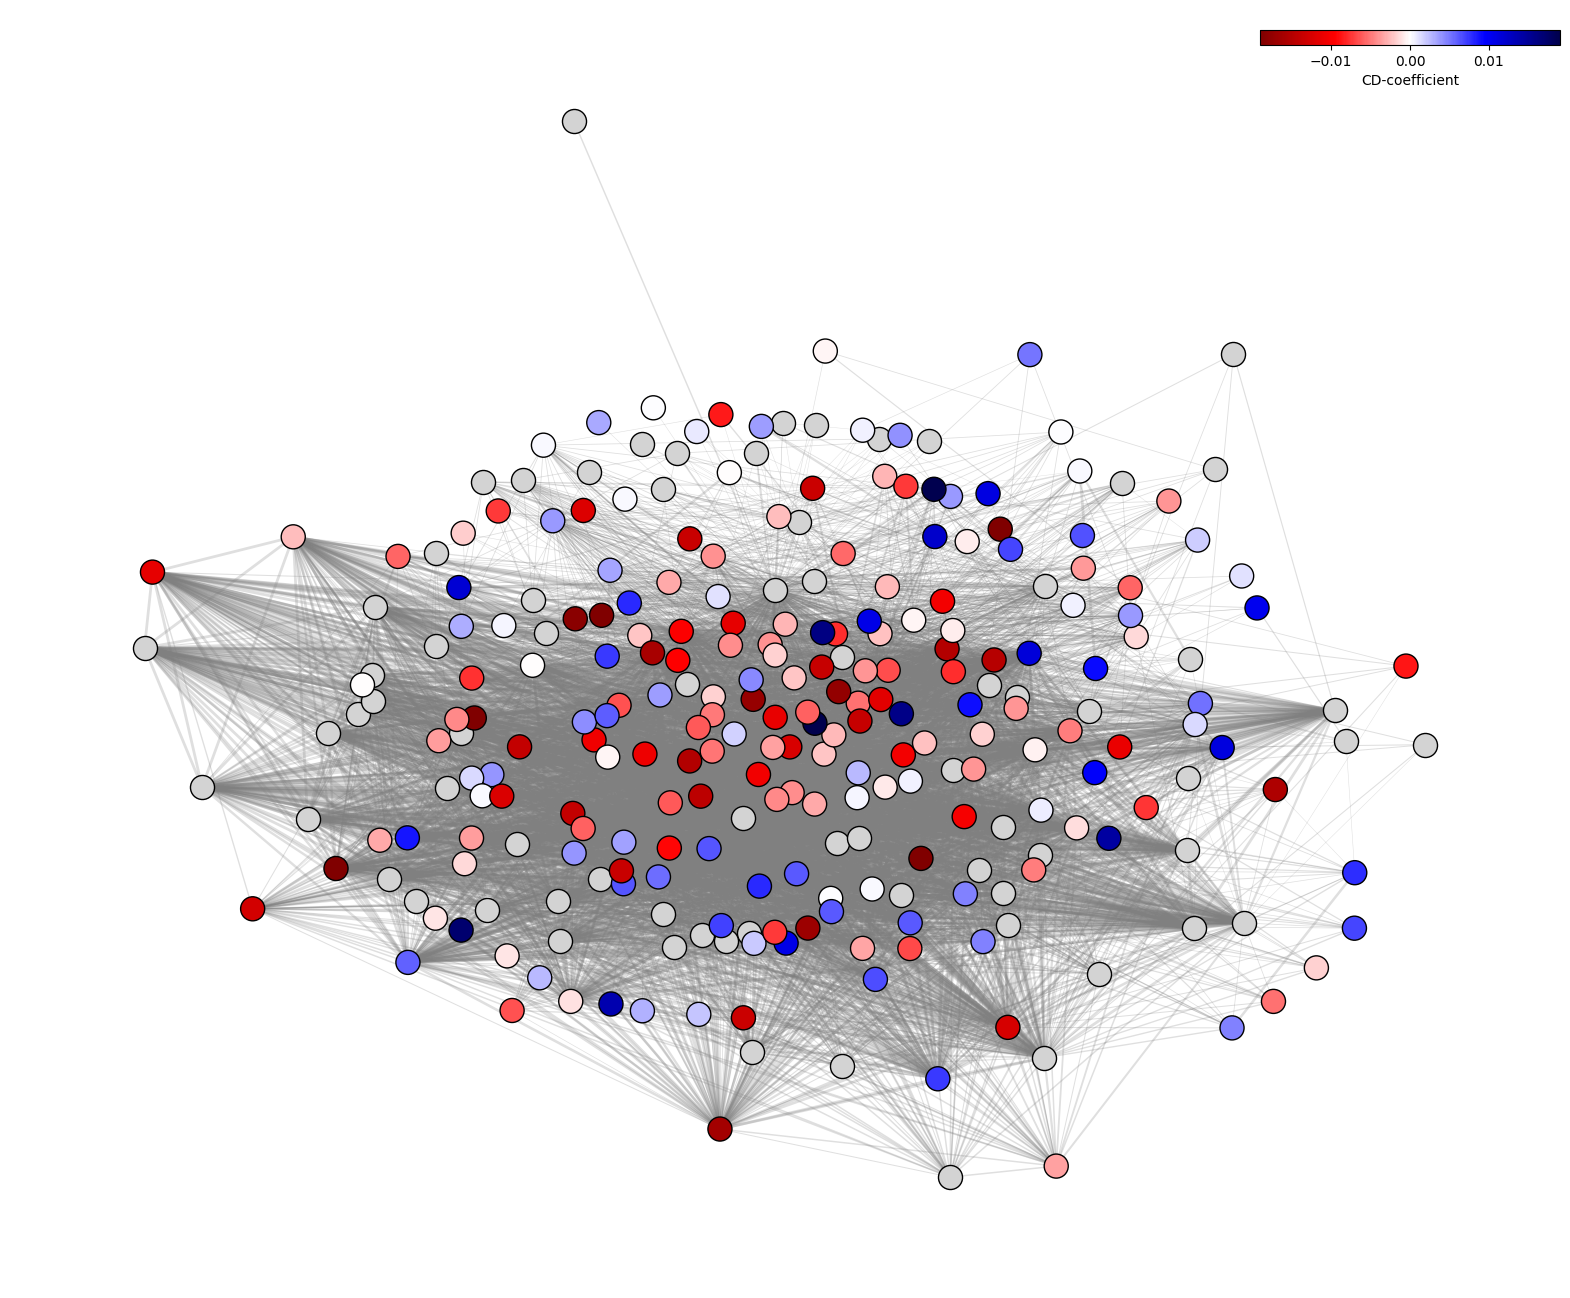

In [23]:
# Visualise network
#graph_visualise_network(graph = ego_graph, pos = ego_pos,  cell_line = 'HT29', drug = 'ibuprofen', dosage = 10, timepoint = 24, title = False,figx = 20, figy = 20, colourbar = True, edge_colour = 'grey', edge_alpha = 0.25)
graph_visualise_network(graph = ego_graph, pos = ego_pos,  cell_line = 'HT29', drug = 'ibuprofen', dosage = 10, timepoint = 24, title = False, figx = 20, figy = 20, vmin = -0.019, vmax = 0.019, colourbar = True, edge_colour = 'grey', edge_alpha = 0.25)

## Hebxin Plot

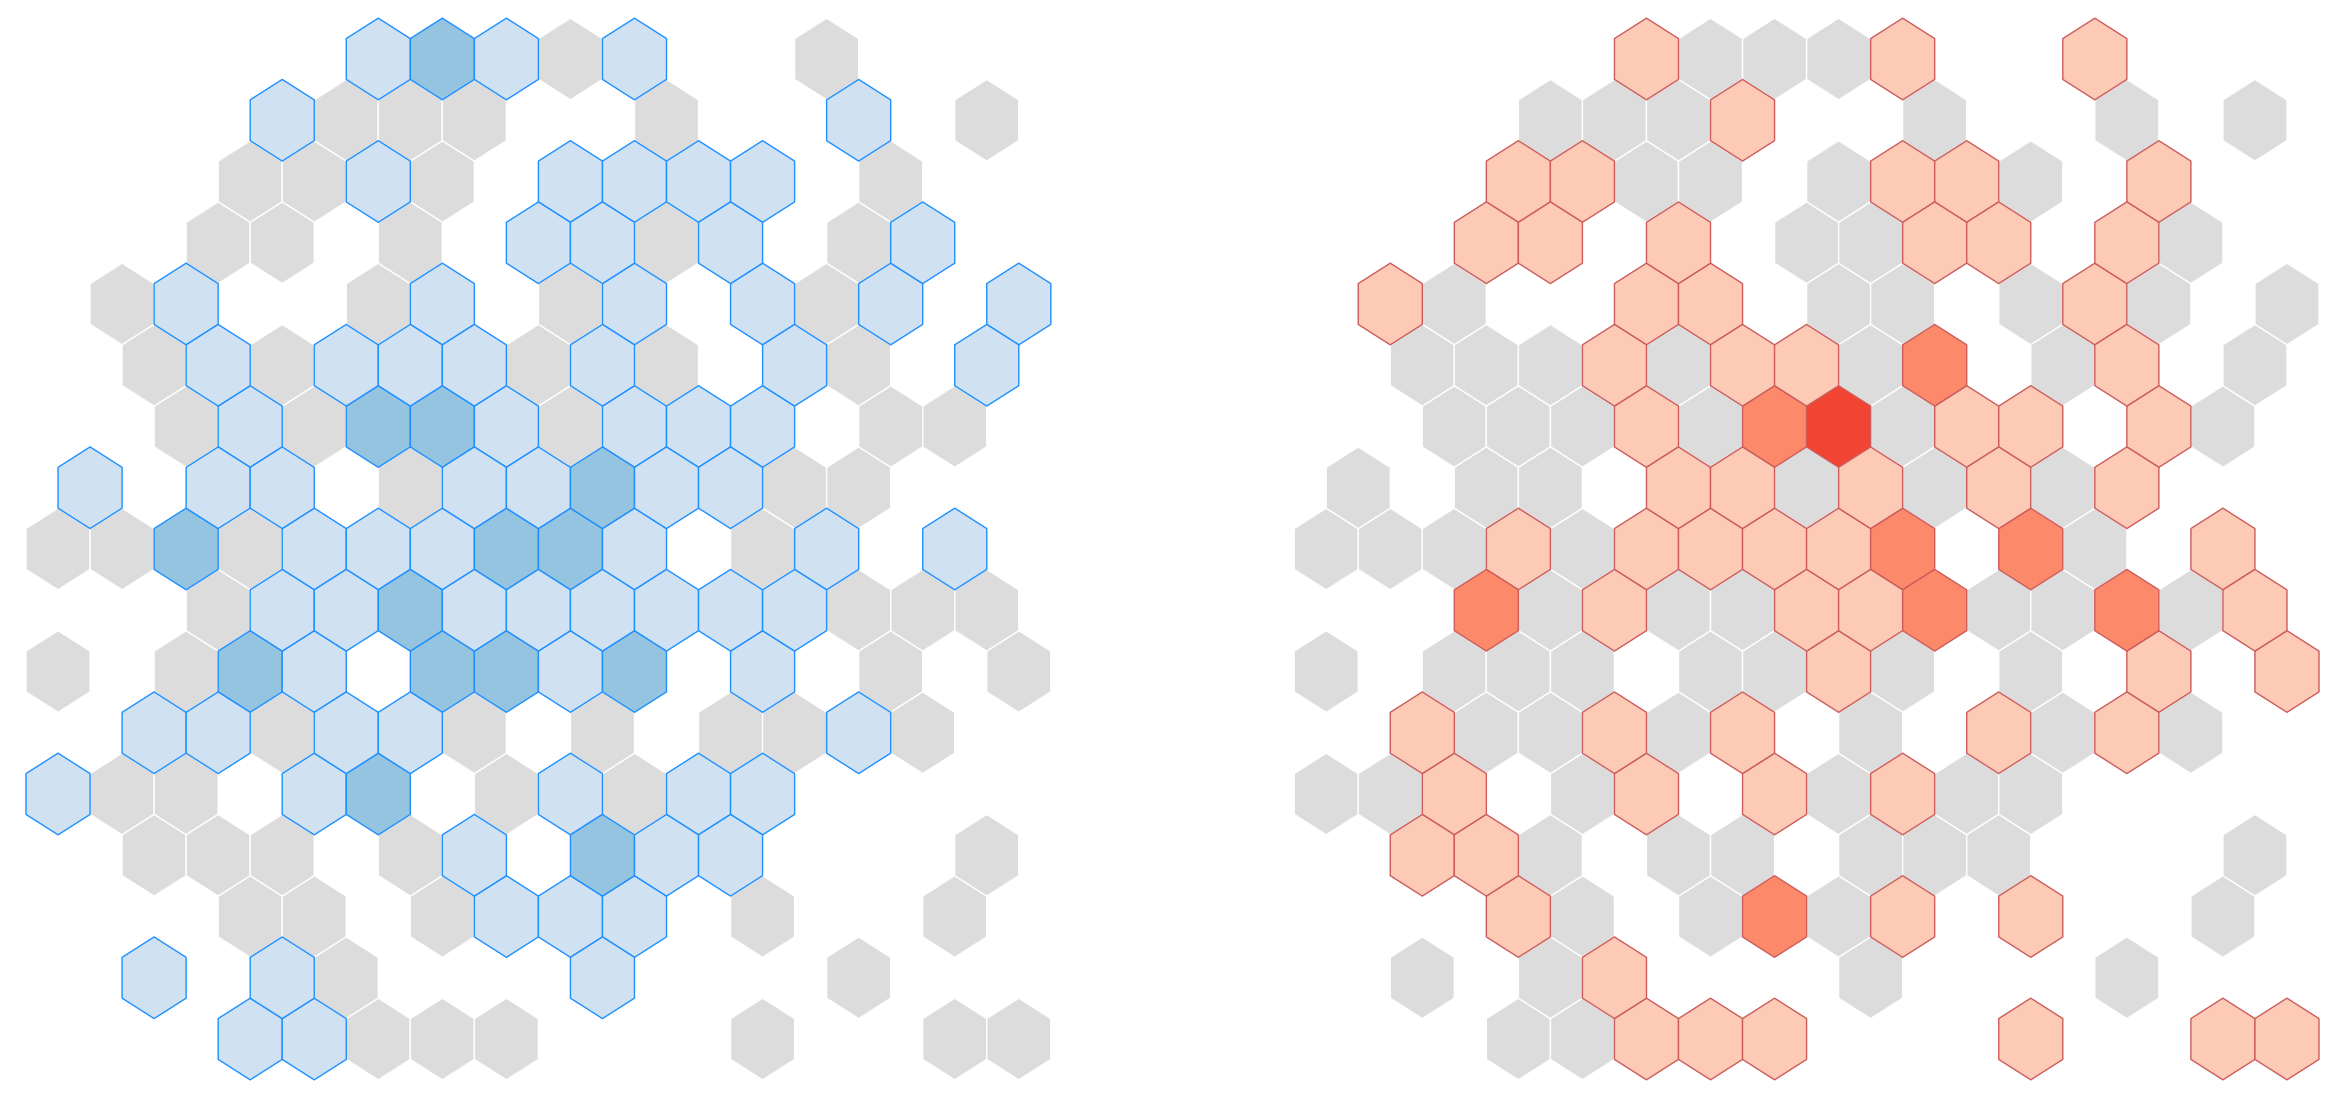

In [25]:
graph_visualise_hex(ego_graph, pos = ego_pos, cell_line = 'HT29', drug = 'ibuprofen', dosage = 10, timepoint = 6, vmax = 5, gridsize = 15)

# Embeddings
In this section, `Graph2Vec` graph embedding output from the `g2v.ipynb` notebook is imported to calculate and visualise cosine distance changes and uMAP dimensionality reduction

## Cosine Distances

In [336]:
# Load df_embeddings
df_embeddings = pd.read_csv(DATAFRAME + 'df_embeddings.csv', index_col = 0)
# Show data
df_embeddings.head()

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
HT29_ceramide_10uM_24,0.850119,1.459740,0.539817,-0.507828,-0.268028,-0.750147,-0.407783,0.447334,-1.157096,-0.564132,...,0.230500,-0.332161,0.298470,0.739336,0.142748,1.014386,-0.438541,0.300555,0.392091,0.756250
HT29_ceramide_10uM_6,0.873862,1.481296,0.540093,-0.519665,-0.263161,-0.761324,-0.415184,0.440858,-1.195708,-0.584396,...,0.238659,-0.333636,0.299644,0.753003,0.142622,1.026267,-0.444824,0.290392,0.403193,0.766710
HT29_chlorphensin_10uM_24,0.877841,1.495315,0.546250,-0.522062,-0.253496,-0.765938,-0.423253,0.442254,-1.216106,-0.597567,...,0.240839,-0.331476,0.302620,0.765402,0.152317,1.040692,-0.450484,0.282319,0.415036,0.775801
HT29_chlorphensin_10uM_6,0.883302,1.495000,0.541848,-0.522729,-0.249061,-0.765856,-0.423721,0.436127,-1.225602,-0.603325,...,0.242739,-0.329017,0.296112,0.764697,0.153701,1.042446,-0.448799,0.279722,0.413629,0.773975
HT29_dihydroobliquin_10uM_24,0.848480,1.446981,0.531791,-0.507678,-0.246504,-0.743218,-0.410661,0.429256,-1.172351,-0.573141,...,0.230495,-0.321947,0.291424,0.744427,0.142826,1.009413,-0.434494,0.278356,0.399672,0.749533


In [337]:
# Calculte cosine distances
matrix_dist = cosine_distances(df_embeddings.values)
# Convert to DataFrame and retain graph names as row and column labels
df_dist = pd.DataFrame(matrix_dist, 
                       index=df_embeddings.index, 
                       columns=df_embeddings.index)
df_dist.reset_index(inplace = True)
df_dist.head()

,index,HT29_ceramide_10uM_24,HT29_ceramide_10uM_6,HT29_chlorphensin_10uM_24,HT29_chlorphensin_10uM_6,HT29_dihydroobliquin_10uM_24,HT29_dihydroobliquin_10uM_6,HT29_dilazep_10uM_24,HT29_dilazep_10uM_6,HT29_dipropyl-dopamine_10uM_24,...,HT29_naltrexone_10uM_24,HT29_naltrexone_10uM_6,HT29_penicillic-acid_10uM_24,HT29_penicillic-acid_10uM_6,HT29_rifaximin_10uM_24,HT29_rifaximin_10uM_6,HT29_simvastatin_10uM_24,HT29_simvastatin_10uM_6,HT29_VAMA-37_10uM_24,HT29_VAMA-37_10uM_6
0,HT29_ceramide_10uM_24,0.000000,0.000092,0.000219,0.000321,0.000180,0.000176,0.000374,0.000641,0.000677,...,0.001714,0.002072,0.001985,0.002089,0.001593,0.001197,0.001308,0.001078,0.000812,0.001185
1,HT29_ceramide_10uM_6,0.000092,0.000000,0.000046,0.000091,0.000037,0.000034,0.000099,0.000261,0.000284,...,0.001048,0.001339,0.001270,0.001364,0.000974,0.000648,0.000762,0.000571,0.000369,0.000642
2,HT29_chlorphensin_10uM_24,0.000219,0.000046,0.000000,0.000019,0.000011,0.000007,0.000062,0.000179,0.000196,...,0.000883,0.001189,0.001124,0.001230,0.000851,0.000540,0.000700,0.000464,0.000245,0.000533
3,HT29_chlorphensin_10uM_6,0.000321,0.000091,0.000019,0.000000,0.000042,0.000038,0.000044,0.000105,0.000120,...,0.000697,0.000998,0.000931,0.001039,0.000685,0.000424,0.000569,0.000333,0.000155,0.000419
4,HT29_dihydroobliquin_10uM_24,0.000180,0.000037,0.000011,0.000042,0.000000,0.000003,0.000085,0.000230,0.000252,...,0.000992,0.001303,0.001233,0.001352,0.000973,0.000607,0.000785,0.000542,0.000303,0.000608


In [338]:
# Melt to dataframe
df_melt = pd.melt(df_dist, id_vars = ['index'])
# Expand columns
df_melt[['cell_line1', 'drug1', 'dosage1', 'timepoint1']] = df_melt['index'].str.split('_', expand = True)
df_melt[['cell_line2', 'drug2', 'dosage2', 'timepoint2']] = df_melt['variable'].str.split('_', expand = True)
df_melt.head()

,index,variable,value,cell_line1,drug1,dosage1,timepoint1,cell_line2,drug2,dosage2,timepoint2
0,HT29_ceramide_10uM_24,HT29_ceramide_10uM_24,0.000000,HT29,ceramide,10uM,24,HT29,ceramide,10uM,24
1,HT29_ceramide_10uM_6,HT29_ceramide_10uM_24,0.000092,HT29,ceramide,10uM,6,HT29,ceramide,10uM,24
2,HT29_chlorphensin_10uM_24,HT29_ceramide_10uM_24,0.000219,HT29,chlorphensin,10uM,24,HT29,ceramide,10uM,24
3,HT29_chlorphensin_10uM_6,HT29_ceramide_10uM_24,0.000321,HT29,chlorphensin,10uM,6,HT29,ceramide,10uM,24
4,HT29_dihydroobliquin_10uM_24,HT29_ceramide_10uM_24,0.000180,HT29,dihydroobliquin,10uM,24,HT29,ceramide,10uM,24


In [339]:
# Extract intra-timepoint comparison
df_6h = df_melt[(df_melt['timepoint1'] == '6') &
                (df_melt['timepoint2'] == '6')]

df_6h = df_6h[['cell_line1', 'drug1', 'dosage1', 'cell_line2', 'drug2', 'dosage2', 'value']]

df_6h = pd.pivot(df_6h, index = 'drug1', columns = 'drug2', values = 'value')
df_6h

drug2,MAZ-51,VAMA-37,ceramide,chlorphensin,dihydroobliquin,dilazep,dipropyl-dopamine,ephedrine,homatropine,ibuprofen,indirubin,indoprofen,mefloquine,mepacrine,naloxone,naltrexone,penicillic-acid,rifaximin,simvastatin
drug1,,,,,,,,,,,,,,,,,,,
MAZ-51,0.000000,0.000135,0.001320,0.000932,0.001232,0.000428,0.000372,0.000275,0.000276,0.000094,0.000112,0.000018,0.000013,0.000017,0.000019,0.000017,0.000034,0.000135,0.000166
VAMA-37,0.000135,0.000000,0.000642,0.000419,0.000590,0.000113,0.000109,0.000049,0.000051,0.000022,0.000048,0.000117,0.000128,0.000125,0.000190,0.000134,0.000154,0.000005,0.000032
ceramide,0.001320,0.000642,0.000000,0.000091,0.000034,0.000261,0.000380,0.000401,0.000413,0.000745,0.000766,0.001207,0.001265,0.001306,0.001470,0.001339,0.001364,0.000648,0.000571
chlorphensin,0.000932,0.000419,0.000091,0.000000,0.000038,0.000105,0.000142,0.000207,0.000208,0.000447,0.000434,0.000840,0.000858,0.000940,0.001083,0.000998,0.001039,0.000424,0.000333
dihydroobliquin,0.001232,0.000590,0.000034,0.000038,0.000000,0.000218,0.000283,0.000358,0.000364,0.000659,0.000657,0.001138,0.001162,0.001212,0.001400,0.001277,0.001324,0.000595,0.000525
dilazep,0.000428,0.000113,0.000261,0.000105,0.000218,0.000000,0.000027,0.000020,0.000022,0.000134,0.000140,0.000367,0.000389,0.000437,0.000526,0.000466,0.000493,0.000118,0.000069
dipropyl-dopamine,0.000372,0.000109,0.000380,0.000142,0.000283,0.000027,0.000000,0.000035,0.000031,0.000100,0.000086,0.000327,0.000319,0.000378,0.000483,0.000429,0.000469,0.000112,0.000076
ephedrine,0.000275,0.000049,0.000401,0.000207,0.000358,0.000020,0.000035,0.000000,0.000005,0.000059,0.000072,0.000227,0.000246,0.000285,0.000355,0.000303,0.000325,0.000051,0.000020
homatropine,0.000276,0.000051,0.000413,0.000208,0.000364,0.000022,0.000031,0.000005,0.000000,0.000064,0.000074,0.000218,0.000238,0.000294,0.000348,0.000304,0.000322,0.000060,0.000022


In [340]:
# Extract intra-timepoint comparison
df_24h = df_melt[(df_melt['timepoint1'] == '24') &
                (df_melt['timepoint2'] == '24')]

df_24h = df_24h[['cell_line1', 'drug1', 'dosage1', 'cell_line2', 'drug2', 'dosage2', 'value']]

df_24h = pd.pivot(df_24h, index = 'drug1', columns = 'drug2', values = 'value')
df_24h

drug2,MAZ-51,VAMA-37,ceramide,chlorphensin,dihydroobliquin,dilazep,dipropyl-dopamine,ephedrine,homatropine,ibuprofen,indirubin,indoprofen,mefloquine,mepacrine,naloxone,naltrexone,penicillic-acid,rifaximin,simvastatin
drug1,,,,,,,,,,,,,,,,,,,
MAZ-51,0.000000,0.000135,0.001550,0.000732,0.000835,0.000427,0.000183,0.000249,0.000070,0.000051,0.000020,0.000006,0.000024,0.000021,0.000042,0.000014,0.000073,0.000051,0.000090
VAMA-37,0.000135,0.000000,0.000812,0.000245,0.000303,0.000092,0.000014,0.000024,0.000059,0.000036,0.000057,0.000159,0.000261,0.000247,0.000308,0.000206,0.000337,0.000227,0.000174
ceramide,0.001550,0.000812,0.000000,0.000219,0.000180,0.000374,0.000677,0.000581,0.001053,0.001147,0.001270,0.001628,0.001919,0.001845,0.002003,0.001714,0.001985,0.001593,0.001308
chlorphensin,0.000732,0.000245,0.000219,0.000000,0.000011,0.000062,0.000196,0.000140,0.000455,0.000448,0.000529,0.000791,0.000996,0.000968,0.001091,0.000883,0.001124,0.000851,0.000700
dihydroobliquin,0.000835,0.000303,0.000180,0.000011,0.000000,0.000085,0.000252,0.000185,0.000529,0.000517,0.000615,0.000891,0.001118,0.001085,0.001210,0.000992,0.001233,0.000973,0.000785
dilazep,0.000427,0.000092,0.000374,0.000062,0.000085,0.000000,0.000061,0.000030,0.000204,0.000219,0.000285,0.000461,0.000639,0.000598,0.000692,0.000529,0.000694,0.000503,0.000364
dipropyl-dopamine,0.000183,0.000014,0.000677,0.000196,0.000252,0.000061,0.000000,0.000013,0.000062,0.000074,0.000097,0.000215,0.000325,0.000302,0.000372,0.000254,0.000394,0.000242,0.000175
ephedrine,0.000249,0.000024,0.000581,0.000140,0.000185,0.000030,0.000013,0.000000,0.000109,0.000109,0.000142,0.000280,0.000412,0.000388,0.000463,0.000329,0.000486,0.000325,0.000241
homatropine,0.000070,0.000059,0.001053,0.000455,0.000529,0.000204,0.000062,0.000109,0.000000,0.000038,0.000048,0.000078,0.000157,0.000122,0.000169,0.000100,0.000163,0.000085,0.000039


In [361]:
# Log values
df_6h_log = np.log2(df_6h)
df_24h_log = np.log2(df_24h)
# Replace infinite values
for df in [df_6h_log, df_24h_log]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

d:\DDesktop\_code\.venv_lincs\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)


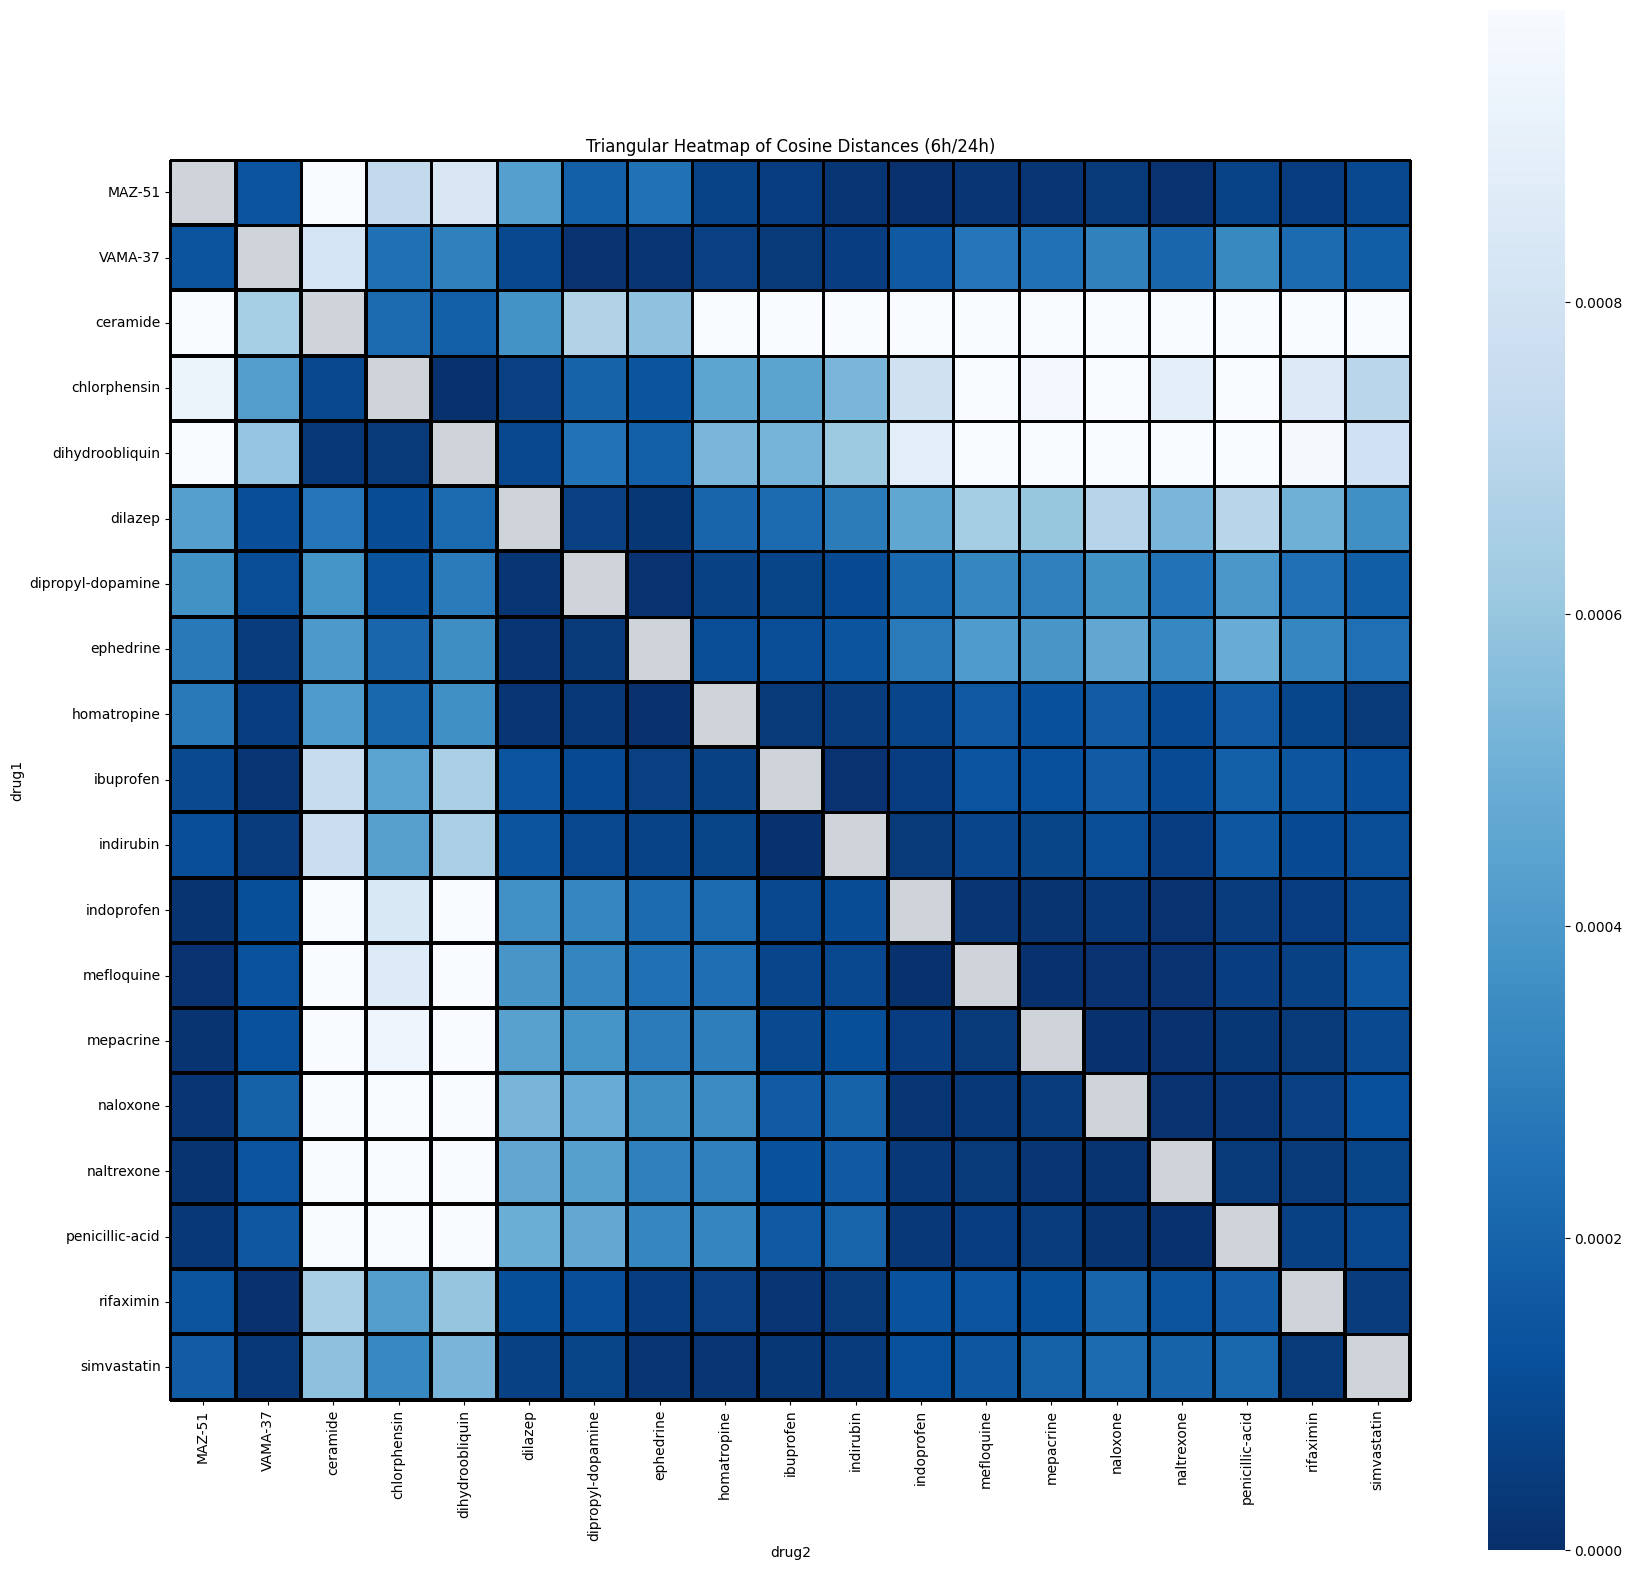

In [344]:
# Get min/max values
max_6h = df_6h.max().max()
max_24h = df_24h.max().max()
hm_max = max(max_6h, max_24h)

min_6h = df_6h.min().min()
min_24h = df_24h.min().min()
hm_min = min(min_6h, min_24h)

# Get distribution of values
all_values = np.concatenate([df_6h.values.ravel(), df_24h.values.ravel()]).tolist()
# Convert the list to a numpy array for easier manipulation
all_values_array = np.array(all_values)
# Calculate Q1, Q3, and IQR
Q1 = np.percentile(all_values_array, 25)
Q3 = np.percentile(all_values_array, 75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Plot triangle heatmaps for 6/24h
# Create a mask for the upper triangle
mask1 = np.triu(np.ones_like(df_6h, dtype = bool))
mask2 = np.tril(np.ones_like(df_24h, dtype = bool))

# Create a mask for the diagonal (to color it separately)
#mask_diag1 = np.eye(df_6h.shape[0], dtype=bool)
mask_diag2 = np.eye(df_24h.shape[0], dtype=bool)

# Create a copy of df_24h
df_24h_nan_diag = df_24h.copy()
# Set diagonal to NaN
np.fill_diagonal(df_24h_nan_diag.values, np.nan)


# Set up the plot
plt.figure(figsize=(20, 20))

sns.heatmap(df_6h, annot=False, fmt=".2e", cmap="Blues_r", 
            vmin = 0, 
            vmax = upper_bound, 
            mask=mask1, cbar=False,
            linewidths=1.5, linecolor = 'black', square=True)
sns.heatmap(df_24h, annot=False, fmt=".2e", cmap="Blues_r", 
            vmin = 0, 
            vmax = upper_bound, 
            mask=mask2, cbar=True,
            linewidths=1, linecolor = 'black', square=True, clip_on = False)
plt.gca().set_facecolor('#ced4da')

# Title and display
plt.title("Triangular Heatmap of Cosine Distances (6h/24h)")
plt.show()

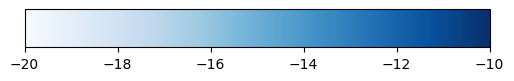

In [326]:
# fig, ax = plt.subplots(figsize=(6, 1))
# fig.subplots_adjust(bottom=0.5)
# norm = mcolors.Normalize(vmin=-20, vmax=-10)
# plt.colorbar(cm.ScalarMappable(norm=norm, cmap='Blues'), cax=ax, orientation='horizontal')

In [335]:
# # Get distribution of values
# all_values = np.concatenate([df_6h_log.values.ravel(), df_24h_log.values.ravel()]).tolist()
# # Convert the list to a numpy array for easier manipulation
# all_values_array = np.array(all_values)

# min_nonzero = np.nanmin(np.where(all_values_array == 0, np.nan, all_values_array))
# print(min_nonzero)

-inf


In [373]:
# Get distribution of values
all_values = np.concatenate([df_6h_log.values.ravel(), df_24h_log.values.ravel()]).tolist()
# Convert the list to a numpy array for easier manipulation
all_values_array = np.array(all_values)

In [376]:
min_value = np.nanmin(all_values_array)
max_value = np.nanmax(all_values_array)


np.float64(-8.963393650310424)

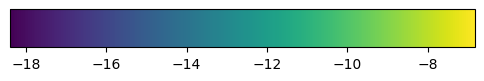

In [408]:
fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)
norm = mcolors.Normalize(vmin=lower_bound, vmax=upper_bound)
plt.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'), cax=ax, orientation='horizontal')

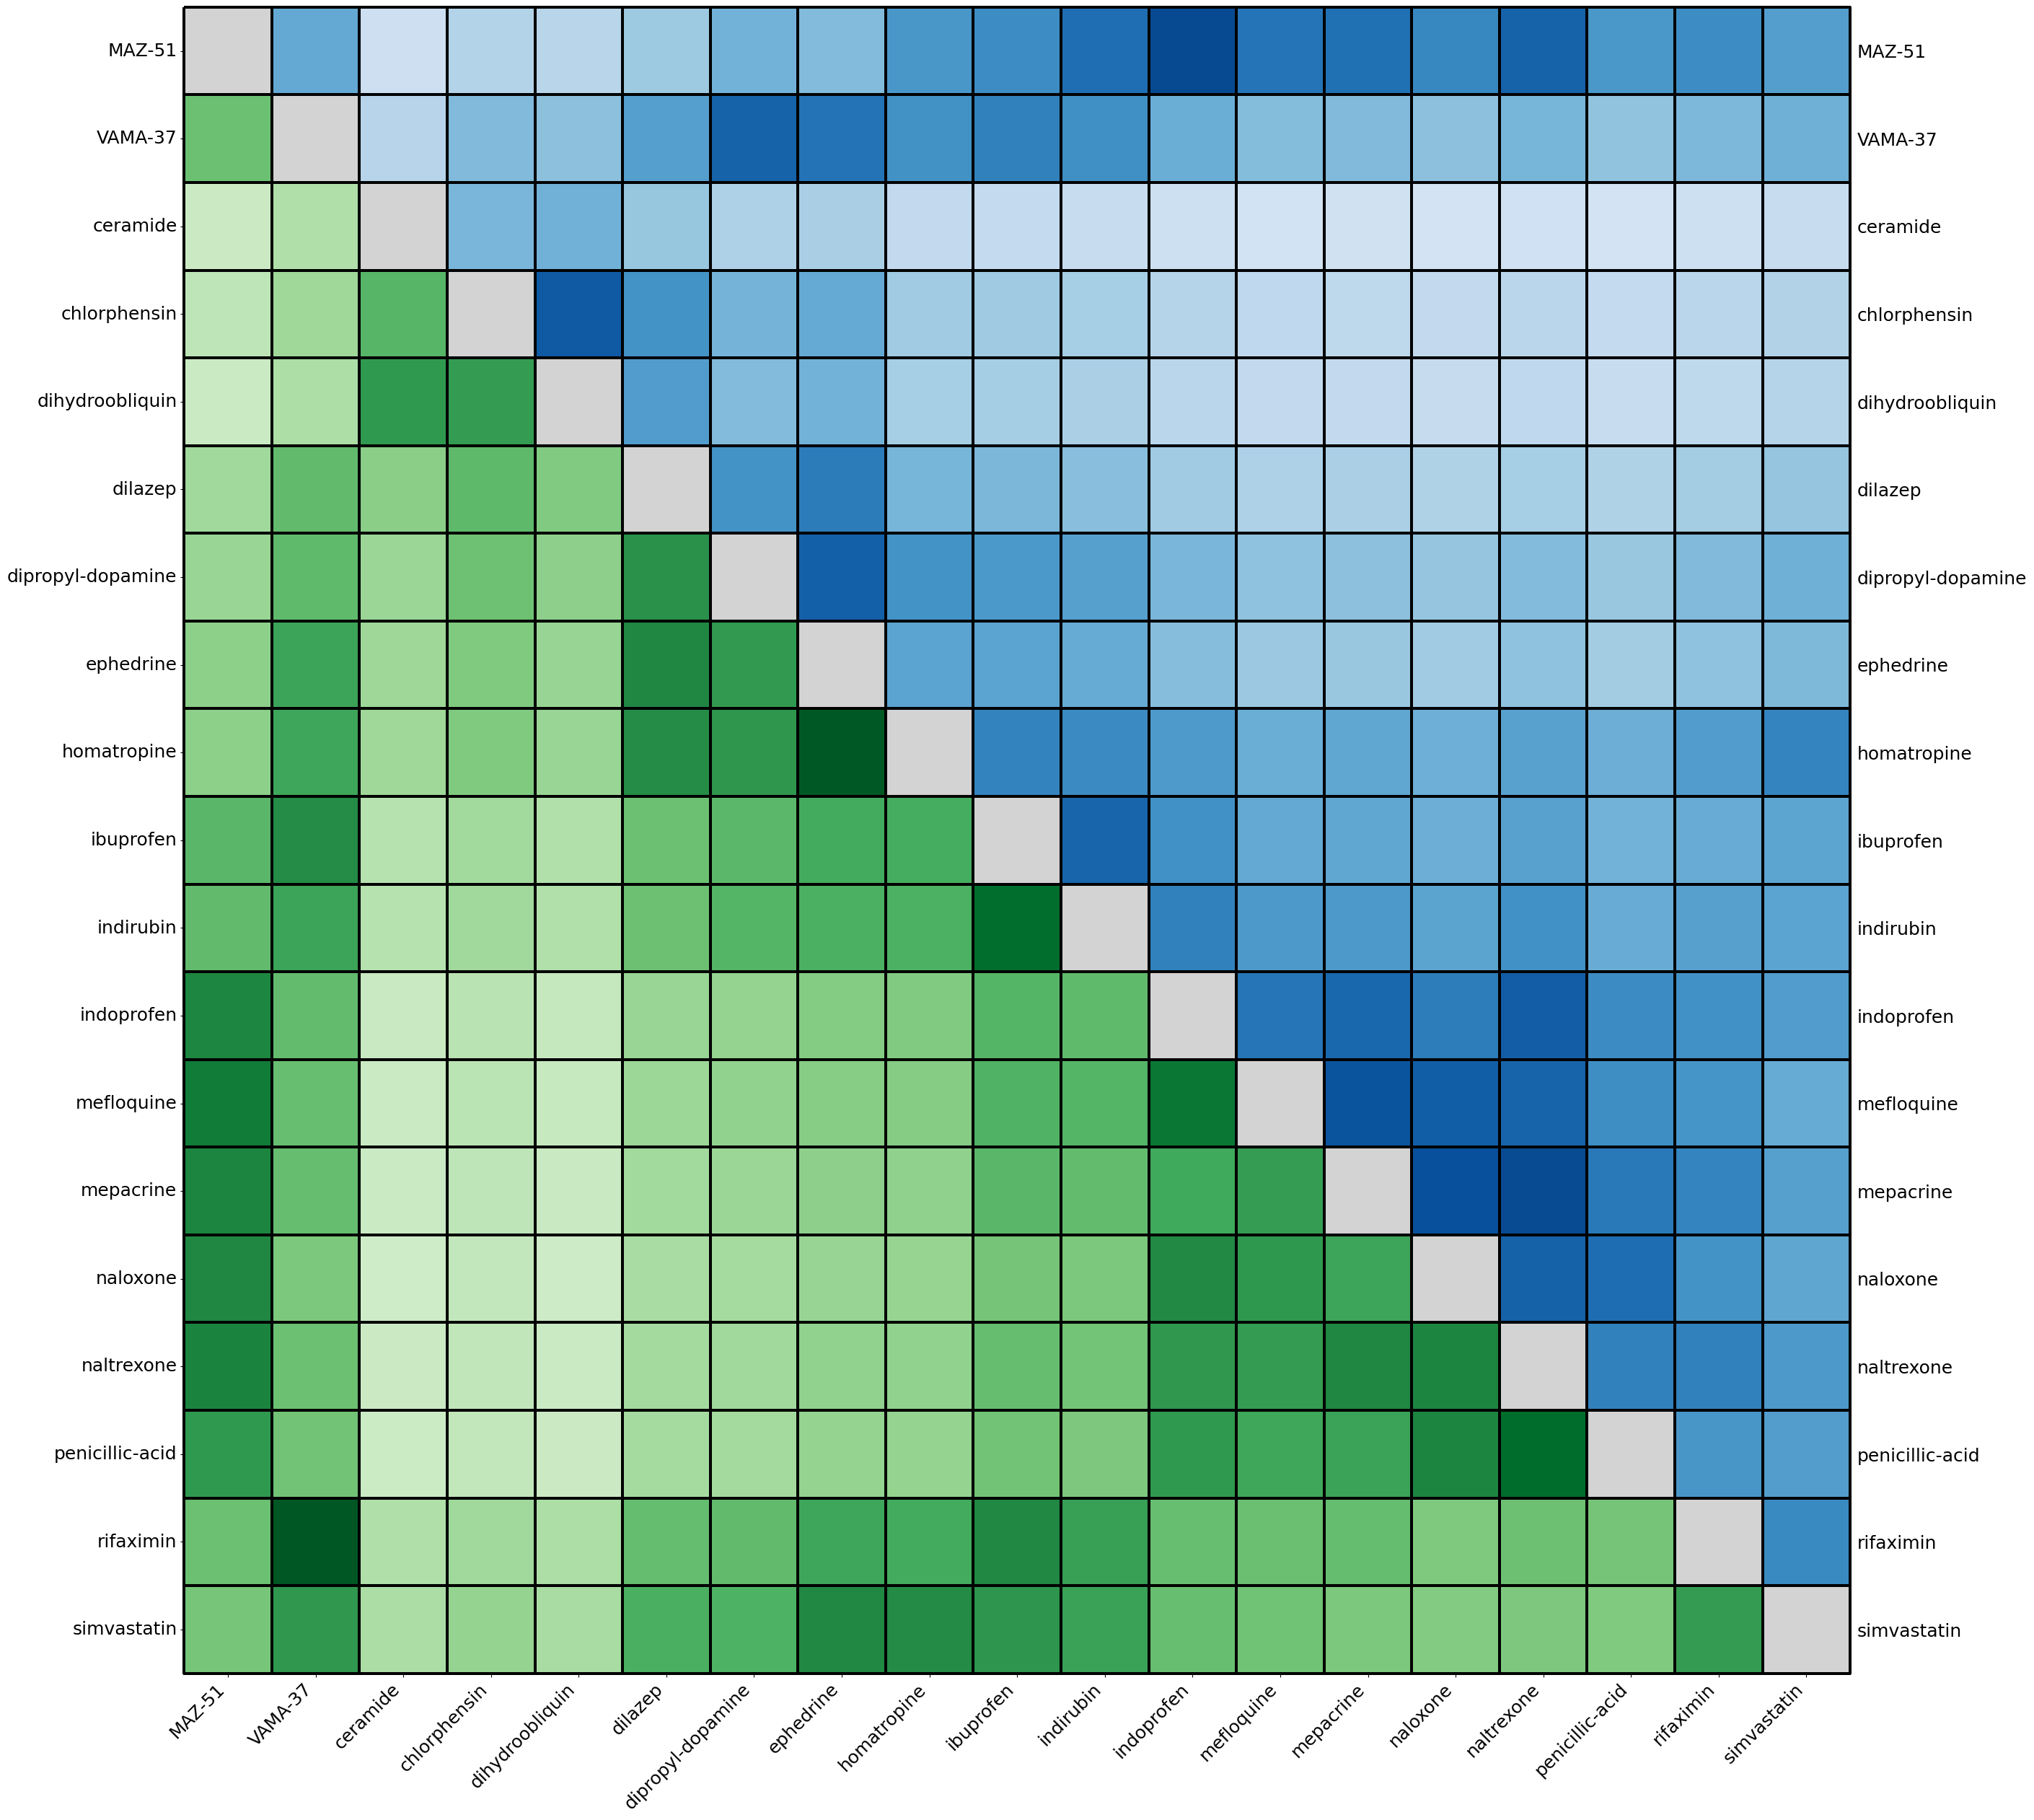

In [410]:
# Get distribution of values
all_values = np.concatenate([df_6h_log.values.ravel(), df_24h_log.values.ravel()]).tolist()
# Convert the list to a numpy array for easier manipulation
all_values_array = np.array(all_values)
# Calculate Q1, Q3, and IQR
q1 = np.nanpercentile(all_values_array, 25)
q3 = np.nanpercentile(all_values_array, 75)
IQR = q3 - q1
upper_bound = q3 + 1.5 * IQR
lower_bound = q1 - 1.5 * IQR

# Plot triangle heatmaps for 6/24h
# Create a mask for the upper triangle
mask1 = np.triu(np.ones_like(df_6h_log, dtype = bool))
mask2 = np.tril(np.ones_like(df_24h_log, dtype = bool))

# Create a mask for the diagonal (to color it separately)
#mask_diag1 = np.eye(df_6h_log.shape[0], dtype=bool)
mask_diag2 = np.eye(df_24h_log.shape[0], dtype=bool)

# Create a copy of df_24h_log
df_24h_log_nan_diag = df_24h_log.copy()
# Set diagonal to NaN
np.fill_diagonal(df_24h_log_nan_diag.values, np.nan)


# Set up the plot
plt.figure(figsize=(30, 30))

sns.heatmap(df_6h_log, 
            annot=False, fmt=".2e", 
            cmap="Greens_r", vmin = lower_bound, vmax = upper_bound, 
            mask=mask1, 
            cbar=False,
            linewidths=1.5, linecolor = 'black', 
            square=True)
sns.heatmap(df_24h_log, annot=False, fmt=".2e", 
            cmap="Blues_r", vmin = lower_bound, vmax = upper_bound, 
            mask=mask2, 
            cbar=False, cbar_kws = {'orientation' : 'horizontal', 'location' : 'top', 'shrink' : 0.25, 'ticks' : [-20, -10], 'aspect' : 10},
            linewidths=1.5, linecolor = 'black', 
            square=True, clip_on = False)
plt.gca().set_facecolor('lightgrey')
plt.yticks(rotation = 0, fontsize = 18)
plt.xlabel('')
plt.ylabel('')
plt.tick_params(axis = 'both', labelbottom = True, labeltop = False, labelsize = 18, labelright = True, labelrotation = 0)
plt.xticks(rotation = 45, fontsize = 18, ha = 'right')

# Title and display
#plt.title("Triangular Heatmap of Cosine Distances (6h/24h)\n", fontsize = 22)
plt.show()

## uMAP

In [378]:
# Load df_embeddings
df_embeddings = pd.read_csv(DATAFRAME + 'df_embeddings.csv', index_col = 0)
# Show data
df_embeddings.head()

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
HT29_ceramide_10uM_24,0.850119,1.459740,0.539817,-0.507828,-0.268028,-0.750147,-0.407783,0.447334,-1.157096,-0.564132,...,0.230500,-0.332161,0.298470,0.739336,0.142748,1.014386,-0.438541,0.300555,0.392091,0.756250
HT29_ceramide_10uM_6,0.873862,1.481296,0.540093,-0.519665,-0.263161,-0.761324,-0.415184,0.440858,-1.195708,-0.584396,...,0.238659,-0.333636,0.299644,0.753003,0.142622,1.026267,-0.444824,0.290392,0.403193,0.766710
HT29_chlorphensin_10uM_24,0.877841,1.495315,0.546250,-0.522062,-0.253496,-0.765938,-0.423253,0.442254,-1.216106,-0.597567,...,0.240839,-0.331476,0.302620,0.765402,0.152317,1.040692,-0.450484,0.282319,0.415036,0.775801
HT29_chlorphensin_10uM_6,0.883302,1.495000,0.541848,-0.522729,-0.249061,-0.765856,-0.423721,0.436127,-1.225602,-0.603325,...,0.242739,-0.329017,0.296112,0.764697,0.153701,1.042446,-0.448799,0.279722,0.413629,0.773975
HT29_dihydroobliquin_10uM_24,0.848480,1.446981,0.531791,-0.507678,-0.246504,-0.743218,-0.410661,0.429256,-1.172351,-0.573141,...,0.230495,-0.321947,0.291424,0.744427,0.142826,1.009413,-0.434494,0.278356,0.399672,0.749533


In [379]:
# Initialise and train uMAP
umap_model = umap.UMAP(n_components = 2, random_state = 42)
embedding_2d = umap_model.fit_transform(df_embeddings.values)

d:\DDesktop\_code\.venv_lincs\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\DDesktop\_code\.venv_lincs\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [380]:
# Convert to df_plot
df_plot = pd.DataFrame(embedding_2d, index = df_embeddings.index)
# Reset index
df_plot.reset_index(inplace = True)
# Expand column
df_plot[['cell_line', 'drug', 'dosage', 'timepoint']] = df_plot['index'].str.split('_', expand = True)
# Drop column
df_plot.drop(columns = ['index'], inplace = True)
# Rename columns
df_plot.rename(columns = {0 : 'x', 1 : 'y'}, inplace = True)
# Column order
column_order = ['cell_line', 'drug', 'dosage', 'timepoint', 'x', 'y']
df_plot = df_plot[column_order]
# Format
df_plot['timepoint'] = df_plot['timepoint'].astype(int)
# Show data
df_plot.head()

,cell_line,drug,dosage,timepoint,x,y
0,HT29,ceramide,10uM,24,12.922703,4.476302
1,HT29,ceramide,10uM,6,13.416338,4.679906
2,HT29,chlorphensin,10uM,24,13.564466,5.184993
3,HT29,chlorphensin,10uM,6,13.373051,5.531085
4,HT29,dihydroobliquin,10uM,24,12.913894,4.242070


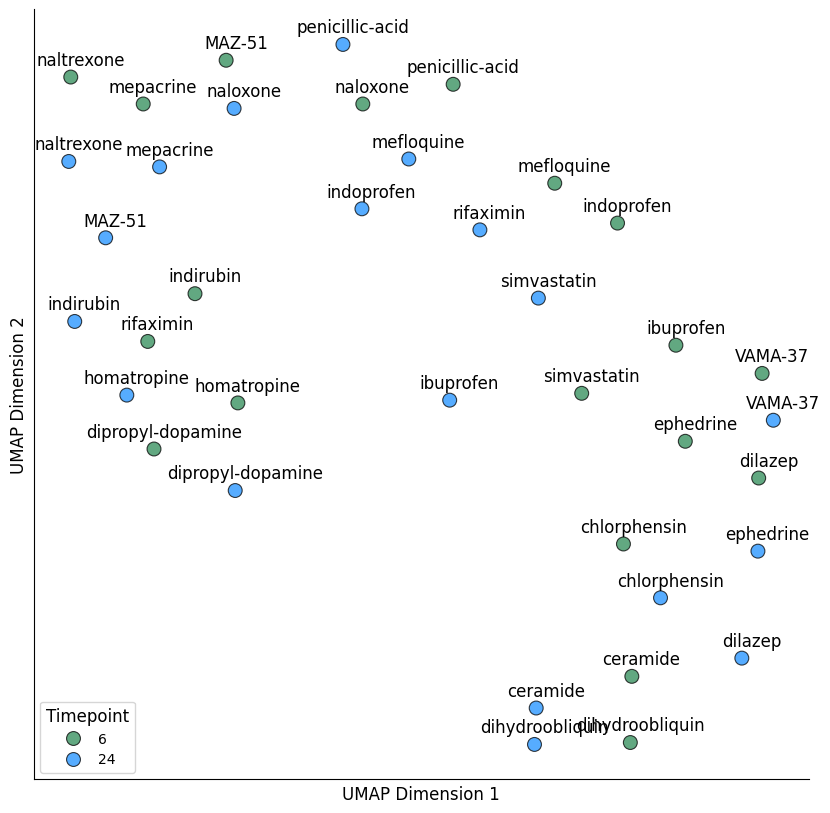

In [400]:
plt.figure(figsize = (10,10))

sns.scatterplot(df_plot, x = 'x', y = 'y', hue = 'timepoint', palette = ['seagreen', 'dodgerblue'], s = 100, alpha = 0.75, edgecolors = 'black')
for i, row in df_plot.iterrows():
    plt.text(row['x'] + 0.05, row['y'] + 0.05, row['drug'], fontsize=12, ha='center', va='bottom')

plt.legend(title = 'Timepoint', loc = 'lower left', title_fontsize = 12)
plt.xlabel("UMAP Dimension 1", fontsize = 12);
plt.ylabel("UMAP Dimension 2", fontsize = 12);
plt.xticks([])
plt.yticks([])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

In [166]:
# # Visualise
# plt.figure(figsize = (10,10))
# plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s = 100)

# for i, name in enumerate(df_embeddings.index):
#     plt.text(embedding_2d[i, 0], embedding_2d[i, 1], name, fontsize=16, alpha=0.7)

# plt.xlabel("UMAP Dimension 1")
# plt.ylabel("UMAP Dimension 2")
# plt.title("Graph Embeddings Projected with UMAP")
# plt.show()